In [1]:
import os, sys

sys.path.append(os.path.abspath('..'))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
env_path = sys.prefix
os.environ['CC'] = f"{env_path}/bin/x86_64-conda-linux-gnu-cc"
os.environ['CXX'] = f"{env_path}/bin/x86_64-conda-linux-gnu-c++"
os.environ['PKG_CONFIG_PATH'] = f"{env_path}/lib/pkgconfig"
os.environ['LD_LIBRARY_PATH'] = f"{env_path}/lib"

os.makedirs('data/models/weights', exist_ok=True)
os.makedirs('data/models/histories', exist_ok=True)

In [2]:
import tensorflow as tf
import numpy as np
import random
import json

from src.networks.DecoderPINN import PINN
from src.networks.Encoder import Encoder
from src.optimization.EncoderTrainer import EncoderTrainer
from src.data.dataloader import load_encoder_data
from src.visualization.historyplots import plot_encoder_adam_history
from src.hyperparameters import hypers_uqvae as h
from src.visualization.pdeplots import N_GRID

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

tf.keras.backend.set_floatx('float32')
number_type = tf.float32


2026-09-10 18:04:11.990398: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789056251.999156  471835 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789056252.001857  471835 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1789056252.008368  471835 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789056252.008382  471835 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789056252.008383  471835 computation_placer.cc:177] computation placer alr

In [3]:
with open('data/models/current_pipeline_id.json', 'r') as f:
    pipeline_id = json.load(f)['latest_id']


U_SCALE = float(np.load('data/models/u_scale_var.npy')[0])
decoder_pinn = PINN(h.N_NEURONS_DECODER, U_SCALE)
decoder_pinn(tf.zeros((1, 4)))
decoder_pinn.load_weights(f'data/models/weights/{pipeline_id}_decoder_lbfgs.weights.h5')
decoder_pinn.trainable = False

I0000 00:00:1789056253.920370  471835 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0


In [4]:
(y_train, u_train), (y_val, u_val), (y_test, u_test), X_obs, sensor_idx, _ = load_encoder_data(
    train_path='data/fem/fem_parametric_train_grid.npz',
    val_path='data/fem/fem_parametric_val_grid.npz',
    test_path='data/fem/fem_parametric_test_grid.npz',
    scale_path='data/models/u_scale_var.npy',
    n_grid=N_GRID,
    n_sensors=h.N_SENSORS,
    region_bounds=h.SENSOR_REGION,
    sensor_idx_path='data/models/sensor_idx.npy',
    noise_level=h.NOISE,
    dtype=number_type
)

U_SCALE (loaded): 0.07060286428244116
Injected Gaussian noise with stddev: 0.02
Shape y_train: (798, 500)  |  Shape u_train: (798, 2)
Shape y_val:   (99, 500)  |  Shape u_val:   (99, 2)
Shape y_test:  (101, 500)  |  Shape u_test:  (101, 2)


In [5]:
encoder = Encoder(n_neurons=h.N_NEURONS_ENCODER, latent_dim=h.D_z)
encoder(tf.zeros((1, h.N_SENSORS)))
encoder.init_output_layer(bias=h.BIAS, weight_scale=h.WEIGHT_SCALE_ENCODER_OUT)

# Optimizer
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    h.LR_ENCODER,
    decay_steps=h.LR_DECAY_STEPS_ENCODER,
    decay_rate=h.LR_DECAY_RATE_ENCODER,
    staircase=False
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
optimizer.build(encoder.trainable_variables)


In [6]:
mu_pr = tf.constant(h.MU_PR, dtype=number_type)
sigma_pr = tf.constant(h.SIGMA_PR, dtype=number_type)
Gamma_pr = tf.eye(h.D_z, dtype=number_type) * (sigma_pr ** 2)
Gamma_pr_inv = tf.linalg.inv(Gamma_pr)
sigma_noise = tf.constant(h.NOISE, dtype=number_type)
mu_E = tf.constant(h.MU_E, dtype=number_type)
u_scale_tf = tf.constant(U_SCALE, dtype=number_type)

train_dataset = (
    tf.data.Dataset.from_tensor_slices((y_train, u_train))
    .shuffle(buffer_size=10000)
    .batch(h.BATCH_SIZE_ENCODER, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE))


I0000 00:00:1789056255.973853  471835 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x5b344a09a500


In [7]:
trainer = EncoderTrainer(encoder=encoder,
                         decoder=decoder_pinn,
                         pipeline_id=pipeline_id)

trainer.train_adam(optimizer=optimizer,
                   epochs=h.EPOCHS_ENCODER_ADAM,
                   train_dataset=train_dataset,
                   y_val=y_val,
                   x_obs=X_obs,
                   mu_pr=mu_pr,
                   Gamma_pr=Gamma_pr,
                   Gamma_pr_inv=Gamma_pr_inv,
                   mu_E=mu_E,
                   sigma_noise=sigma_noise,
                   u_scale=u_scale_tf,
                   patience=h.PATIENCE_ENCODER_ADAM,
                   save_freq=h.SAVE_FREQ_ENCODER_ADAM)



Starting Encoder Adam optimization...


I0000 00:00:1789056256.894708  471835 service.cc:152] XLA service 0x5b345549ccf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789056256.894753  471835 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 5080, Compute Capability 12.0
I0000 00:00:1789056257.271893  471835 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1789056261.724030  471835 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch    0 | Loss: 4.3252e+03 | Data Fid: 4.3246e+03 | Val Loss: 3.5726e+03 | Val Data Fid: 3.5724e+03
Epoch  100 | Loss: 1.1480e+03 | Data Fid: 1.1464e+03 | Val Loss: 2.4974e+02 | Val Data Fid: 2.4869e+02
Epoch  200 | Loss: 5.9441e+02 | Data Fid: 5.9364e+02 | Val Loss: 1.7149e+02 | Val Data Fid: 1.7066e+02
Epoch  300 | Loss: 5.6844e+02 | Data Fid: 5.6750e+02 | Val Loss: 7.9068e+01 | Val Data Fid: 7.8267e+01
Epoch  400 | Loss: 5.4054e+02 | Data Fid: 5.3943e+02 | Val Loss: 5.5575e+01 | Val Data Fid: 5.4741e+01
Epoch  500 | Loss: 5.3626e+02 | Data Fid: 5.3510e+02 | Val Loss: 5.8871e+01 | Val Data Fid: 5.7961e+01
Epoch  600 | Loss: 5.3558e+02 | Data Fid: 5.3464e+02 | Val Loss: 5.1279e+01 | Val Data Fid: 5.0366e+01
Epoch  700 | Loss: 5.4878e+02 | Data Fid: 5.4783e+02 | Val Loss: 4.4688e+01 | Val Data Fid: 4.3848e+01
Epoch  800 | Loss: 5.3285e+02 | Data Fid: 5.3198e+02 | Val Loss: 6.5993e+01 | Val Data Fid: 6.5040e+01
Epoch  900 | Loss: 5.2311e+02 | Data Fid: 5.2231e+02 | Val Loss: 4.2255e+

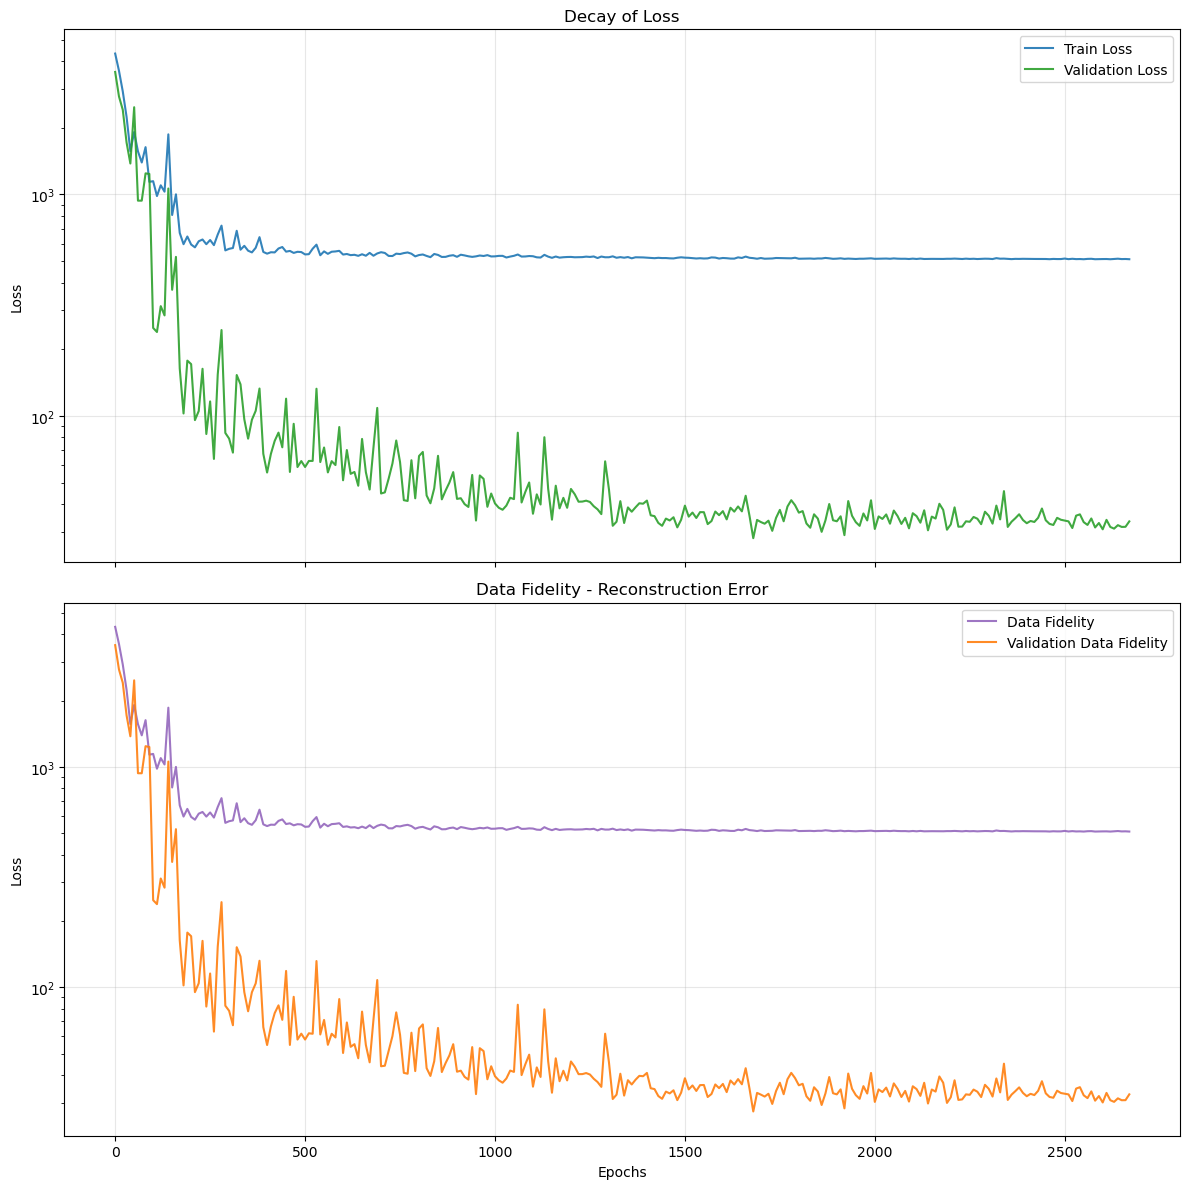

In [8]:
plot_encoder_adam_history(trainer.history_adam, save_freq=h.SAVE_FREQ_ENCODER_ADAM)

In [9]:
# check 
encoder.load_weights(f'data/models/weights/{pipeline_id}_encoder_adam.weights.h5')

qz_val = encoder(y_val)
u_pred_val = qz_val.mean().numpy()

mae_u = np.mean(np.abs(u_pred_val - u_val.numpy()), axis=0)
print(f"Errore MAE su cx (Centro X): {mae_u[0]:.4f}")
print(f"Errore MAE su cy (Centro Y): {mae_u[1]:.4f}\n")

print("Confronto True vs Pred (primi 5 campioni):")
for i in range(5):
    print(f"True [cx, cy]: {u_val[i].numpy()} | Pred [cx, cy]: {u_pred_val[i]}")

Errore MAE su cx (Centro X): 0.0275
Errore MAE su cy (Centro Y): 0.0388

Confronto True vs Pred (primi 5 campioni):
True [cx, cy]: [0.492 0.394] | Pred [cx, cy]: [0.46556047 0.36300996]
True [cx, cy]: [0.432 0.626] | Pred [cx, cy]: [0.43237662 0.6365133 ]
True [cx, cy]: [0.5   0.334] | Pred [cx, cy]: [0.55436975 0.35831064]
True [cx, cy]: [0.613 0.285] | Pred [cx, cy]: [0.6282472  0.34014454]
True [cx, cy]: [0.619 0.485] | Pred [cx, cy]: [0.6242652 0.4825998]
